In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("dataset.csv")

In [ ]:
print(df.isnull().sum())

MZ-7.86E-05      0
MZ2.18E-07       0
MZ9.60E-05       0
MZ0.000366014    0
MZ0.000810195    0
                ..
MZ19987.596      0
MZ19990.235      0
MZ19992.874      0
MZ19995.513      0
Class            0
Length: 15155, dtype: int64


In [ ]:
print(df.shape )

(253, 15155)


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

In [ ]:

scaler_chi = MinMaxScaler()
X_train_scaled = scaler_chi.fit_transform(X_train)
X_test_scaled = scaler_chi.transform(X_test)

In [ ]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_scaled)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imputed, y_train)

In [ ]:
k_features = 70
chi_selector = SelectKBest(score_func=chi2,
                           )
X_train_selected = chi_selector.fit_transform(X_train_res, y_train_res)
X_test_selected = chi_selector.transform(X_test_scaled)

selected_features = X.columns[chi_selector.get_support()]
print("Nombre de caractéristiques après sélection :", X_train_selected.shape[1])
print("Caractéristiques sélectionnées :", list(selected_features))

Nombre de caractéristiques après sélection : 10
Caractéristiques sélectionnées : ['MZ244.36855', 'MZ244.66041', 'MZ244.95245', 'MZ245.24466', 'MZ245.53704', 'MZ245.8296', 'MZ246.12233', 'MZ246.41524', 'MZ246.70832', 'MZ417.73207']


In [ ]:
scaler_model = StandardScaler()
X_train_final = scaler_model.fit_transform(X_train_selected)
X_test_final = scaler_model.transform(X_test_selected)


In [ ]:
from sklearn.linear_model import LogisticRegression

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "LogisticRegression": LogisticRegression()
}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_final, y_train_res)
    y_pred = model.predict(X_test_final)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc


print("\nPrécision de chaque modèle après sélection des caractéristiques :")
for name, acc in results.items():
    print(f"{name} : {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\nMeilleur modèle : {best_model} avec une précision de {results[best_model]:.4f}")


Précision de chaque modèle après sélection des caractéristiques :
KNN : 0.9804
SVM : 0.9804
Arbre de décision : 0.9510
Naive Bayes : 0.9706
LogisticRegression : 0.9706

Meilleur modèle : KNN avec une précision de 0.9804


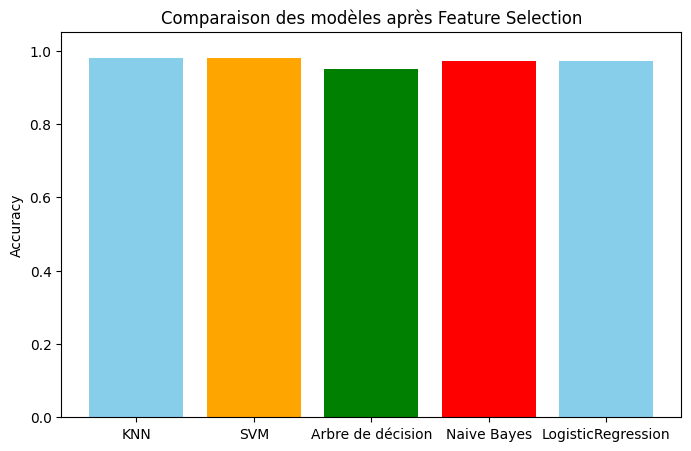


--- KNN ---
Confusion Matrix :
 [[64  1]
 [ 1 36]]


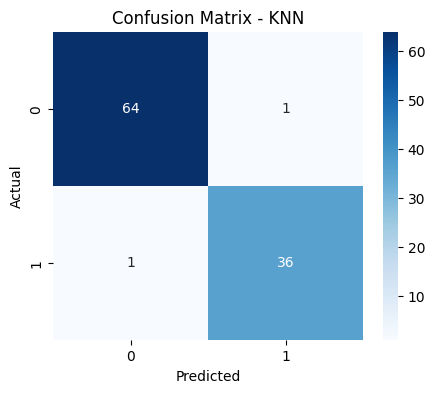


Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        65
           1       0.97      0.97      0.97        37

    accuracy                           0.98       102
   macro avg       0.98      0.98      0.98       102
weighted avg       0.98      0.98      0.98       102


--- SVM ---
Confusion Matrix :
 [[64  1]
 [ 1 36]]


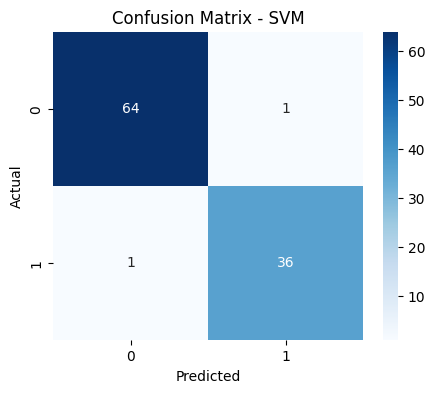


Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        65
           1       0.97      0.97      0.97        37

    accuracy                           0.98       102
   macro avg       0.98      0.98      0.98       102
weighted avg       0.98      0.98      0.98       102


--- Arbre de décision ---
Confusion Matrix :
 [[62  3]
 [ 2 35]]


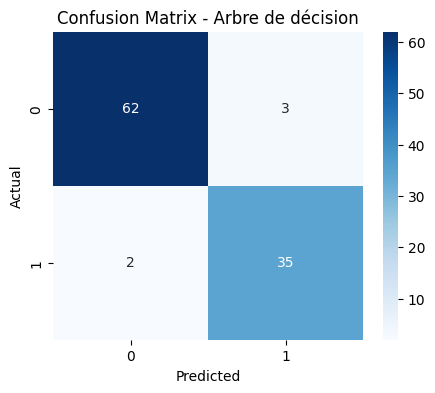


Classification Report :
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        65
           1       0.92      0.95      0.93        37

    accuracy                           0.95       102
   macro avg       0.94      0.95      0.95       102
weighted avg       0.95      0.95      0.95       102


--- Naive Bayes ---
Confusion Matrix :
 [[63  2]
 [ 1 36]]


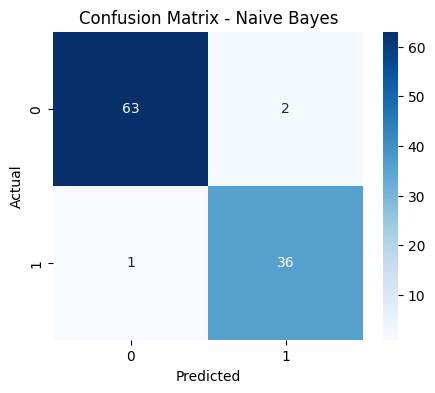


Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        65
           1       0.95      0.97      0.96        37

    accuracy                           0.97       102
   macro avg       0.97      0.97      0.97       102
weighted avg       0.97      0.97      0.97       102


--- LogisticRegression ---
Confusion Matrix :
 [[63  2]
 [ 1 36]]


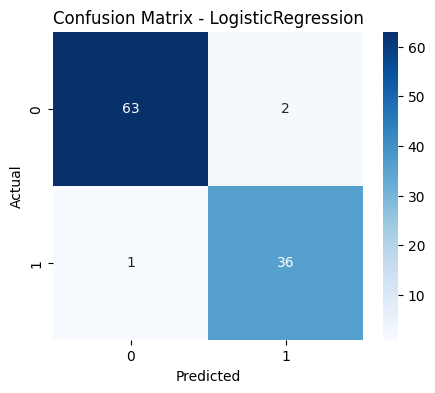


Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        65
           1       0.95      0.97      0.96        37

    accuracy                           0.97       102
   macro avg       0.97      0.97      0.97       102
weighted avg       0.97      0.97      0.97       102



In [ ]:

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['skyblue','orange','green','red'])
plt.ylim(0,1.05)
plt.ylabel("Accuracy")
plt.title("Comparaison des modèles après Feature Selection")
plt.show()


for name, y_pred in predictions.items():
    print(f"\n--- {name} ---")
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix :\n", cm)


    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nClassification Report :")
    print(classification_report(y_test, y_pred))

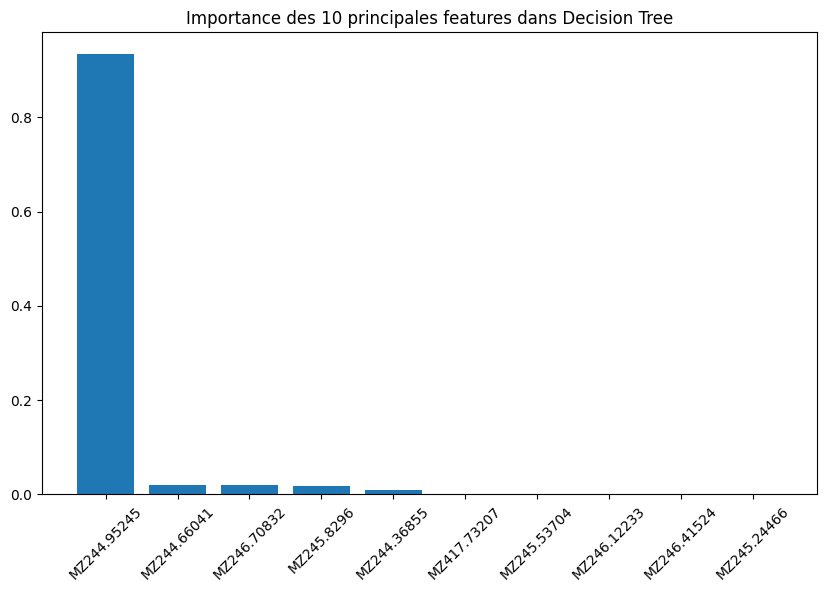

In [ ]:
import numpy as np
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_final, y_train_res)


importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]


plt.figure(figsize=(10,6))
plt.title("Importance des 10 principales features dans Decision Tree")
plt.bar(range(10), importances[indices][:10], align='center')
plt.xticks(range(10), selected_features[indices][:10], rotation=45)
plt.show()

In [ ]:
from sklearn.feature_selection import SelectFpr, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
scaler_chi = MinMaxScaler()
X_train_scaled = scaler_chi.fit_transform(X_train_res)

selector = SelectFpr(score_func=chi2, alpha=0.05)
X_train_selected = selector.fit_transform(X_train_scaled, y_train_res)

X_test_scaled = scaler_chi.transform(X_test)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Nombre de features après sélection :", X_train_selected.shape[1])
print("Features sélectionnées :", list(selected_features))

Nombre de features après sélection : 1738
Features sélectionnées : ['MZ0.70624794', 'MZ0.82031535', 'MZ0.96112942', 'MZ2.7610465', 'MZ2.7921478', 'MZ2.8234234', 'MZ2.8548732', 'MZ2.8864971', 'MZ2.9182952', 'MZ2.9502676', 'MZ2.9824141', 'MZ4.3330551', 'MZ15.221106', 'MZ24.933227', 'MZ25.119975', 'MZ25.21361', 'MZ25.307419', 'MZ25.401403', 'MZ25.49556', 'MZ25.589892', 'MZ25.684398', 'MZ25.779078', 'MZ25.873933', 'MZ25.968961', 'MZ26.064164', 'MZ26.159541', 'MZ26.255092', 'MZ26.350818', 'MZ26.446717', 'MZ26.542791', 'MZ26.639039', 'MZ26.735461', 'MZ26.832057', 'MZ26.928828', 'MZ27.025772', 'MZ27.122891', 'MZ27.220184', 'MZ27.317652', 'MZ27.415293', 'MZ27.513109', 'MZ27.611098', 'MZ27.709262', 'MZ27.807601', 'MZ27.906113', 'MZ28.0048', 'MZ28.10366', 'MZ28.202695', 'MZ28.301904', 'MZ28.401288', 'MZ28.500845', 'MZ28.600577', 'MZ28.700483', 'MZ28.800563', 'MZ28.900817', 'MZ29.001246', 'MZ29.101848', 'MZ29.202625', 'MZ29.303576', 'MZ29.404701', 'MZ29.506001', 'MZ29.607474', 'MZ29.709122', 'MZ2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(



Précision de chaque modèle après sélection par p-value :
KNN : 0.9314
SVM : 0.9804
Arbre de décision : 0.9118
Naive Bayes : 0.9020
LogisticRegression : 1.0000

Meilleur modèle : LogisticRegression avec une précision de 1.0000


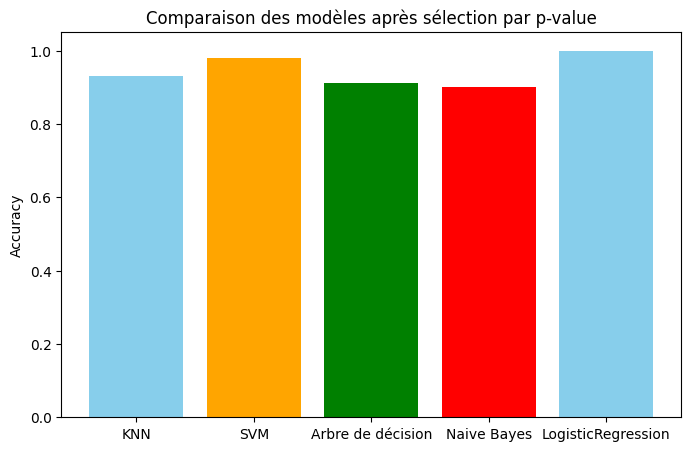

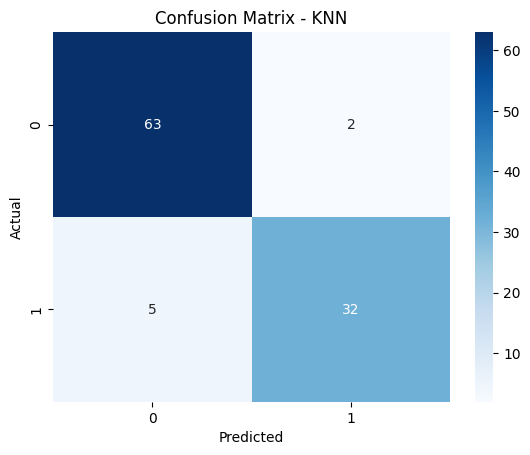


Classification Report - KNN :
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        65
           1       0.94      0.86      0.90        37

    accuracy                           0.93       102
   macro avg       0.93      0.92      0.92       102
weighted avg       0.93      0.93      0.93       102



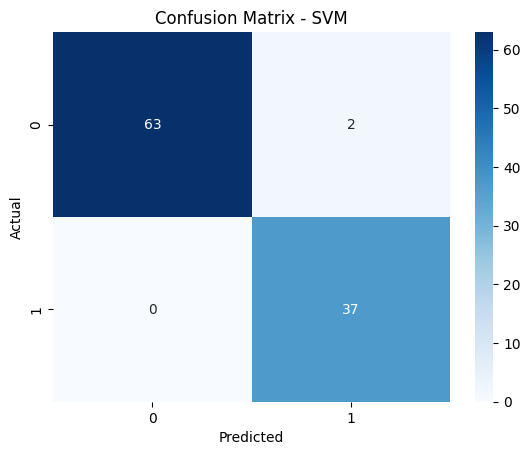


Classification Report - SVM :
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        65
           1       0.95      1.00      0.97        37

    accuracy                           0.98       102
   macro avg       0.97      0.98      0.98       102
weighted avg       0.98      0.98      0.98       102



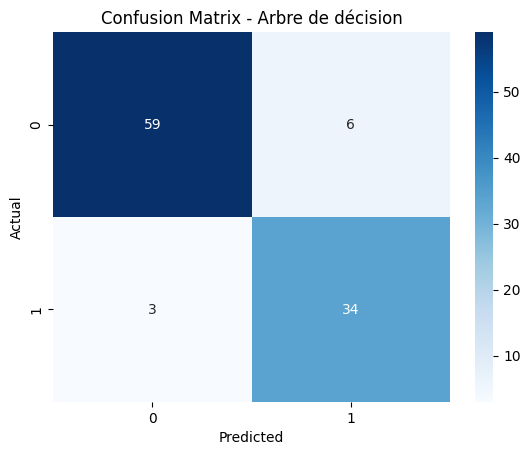


Classification Report - Arbre de décision :
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        65
           1       0.85      0.92      0.88        37

    accuracy                           0.91       102
   macro avg       0.90      0.91      0.91       102
weighted avg       0.91      0.91      0.91       102



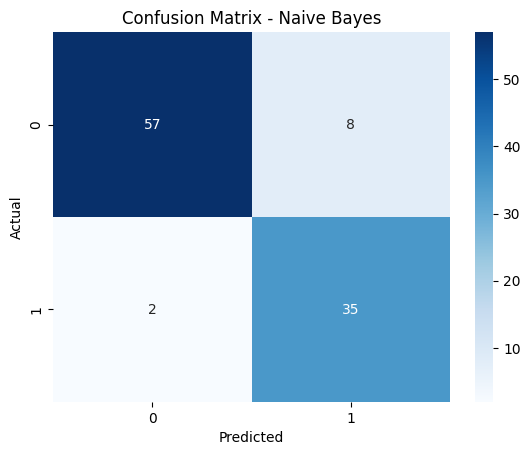


Classification Report - Naive Bayes :
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        65
           1       0.81      0.95      0.88        37

    accuracy                           0.90       102
   macro avg       0.89      0.91      0.90       102
weighted avg       0.91      0.90      0.90       102



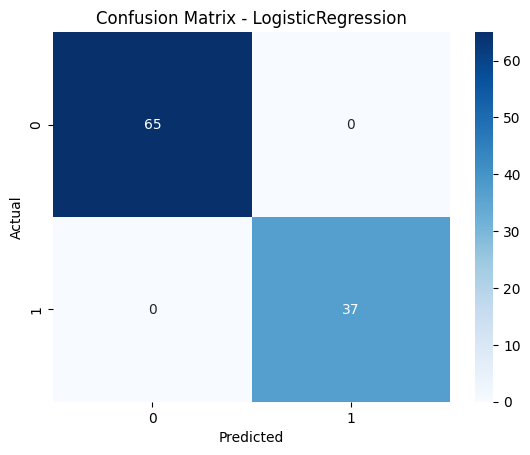


Classification Report - LogisticRegression :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        37

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102



In [ ]:
from sklearn.linear_model import LogisticRegression

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "LogisticRegression": LogisticRegression()
}


results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

print("\nPrécision de chaque modèle après sélection par p-value :")
for name, acc in results.items():
    print(f"{name} : {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\nMeilleur modèle : {best_model} avec une précision de {results[best_model]:.4f}")


plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['skyblue','orange','green','red'])
plt.ylim(0,1.05)
plt.ylabel("Accuracy")
plt.title("Comparaison des modèles après sélection par p-value")
plt.show()


for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(f"\nClassification Report - {name} :")
    print(classification_report(y_test, y_pred))

Mutual Information

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

k_features = 70
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
X_train_selected = mi_selector.fit_transform(X_train_res, y_train_res)
X_test_selected = mi_selector.transform(X_test_scaled)

selected_features = X.columns[mi_selector.get_support()]
print("Nombre de caractéristiques après sélection :", X_train_selected.shape[1])
print("Caractéristiques sélectionnées :", list(selected_features))

Nombre de caractéristiques après sélection : 70
Caractéristiques sélectionnées : ['MZ2.7921478', 'MZ2.8234234', 'MZ25.49556', 'MZ25.589892', 'MZ25.684398', 'MZ25.779078', 'MZ220.47402', 'MZ220.75125', 'MZ221.86191', 'MZ222.14001', 'MZ222.41828', 'MZ222.69673', 'MZ222.97536', 'MZ223.25415', 'MZ243.49401', 'MZ243.78535', 'MZ244.07686', 'MZ244.36855', 'MZ244.66041', 'MZ244.95245', 'MZ245.24466', 'MZ245.53704', 'MZ245.8296', 'MZ246.12233', 'MZ246.41524', 'MZ246.70832', 'MZ247.00158', 'MZ247.295', 'MZ247.58861', 'MZ247.88239', 'MZ248.17634', 'MZ261.28267', 'MZ261.58446', 'MZ261.88643', 'MZ262.18857', 'MZ262.49088', 'MZ409.75936', 'MZ410.13727', 'MZ416.96946', 'MZ417.35068', 'MZ417.73207', 'MZ418.11364', 'MZ418.49538', 'MZ418.8773', 'MZ433.90794', 'MZ434.29682', 'MZ434.68588', 'MZ435.07512', 'MZ435.46452', 'MZ435.85411', 'MZ436.24386', 'MZ436.63379', 'MZ437.0239', 'MZ462.35287', 'MZ463.55767', 'MZ463.95962', 'MZ464.36174', 'MZ464.76404', 'MZ465.16651', 'MZ465.56916', 'MZ4003.6449', 'MZ4004.8

In [ ]:

scaler_model = StandardScaler()
X_train_final = scaler_model.fit_transform(X_train_selected)
X_test_final = scaler_model.transform(X_test_selected)

In [ ]:

from sklearn.linear_model import LogisticRegression

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "LogisticRegression": LogisticRegression()
}

results = {}
predictions = {}
execution_times = {}
import time
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_final, y_train_res)
    y_pred = model.predict(X_test_final)
    end_time = time.time()

    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    execution_times[name] = end_time - start_time

print("\nPrécision et temps d'exécution pour chaque modèle :")
for name in models.keys():
    print(f"{name} : précision={results[name]:.4f}, temps={execution_times[name]:.2f} sec")

best_model = max(results, key=results.get)
print(f"\nMeilleur modèle : {best_model} avec précision={results[best_model]:.4f}")

for name, y_pred in predictions.items():
    print(f"\nClassification Report pour {name} :")
    print(classification_report(y_test, y_pred))


Précision et temps d'exécution pour chaque modèle :
KNN : précision=1.0000, temps=0.01 sec
SVM : précision=1.0000, temps=0.01 sec
Arbre de décision : précision=0.9118, temps=0.01 sec
Naive Bayes : précision=0.9706, temps=0.00 sec
LogisticRegression : précision=1.0000, temps=0.09 sec

Meilleur modèle : KNN avec précision=1.0000

Classification Report pour KNN :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        37

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102


Classification Report pour SVM :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        37

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
wei

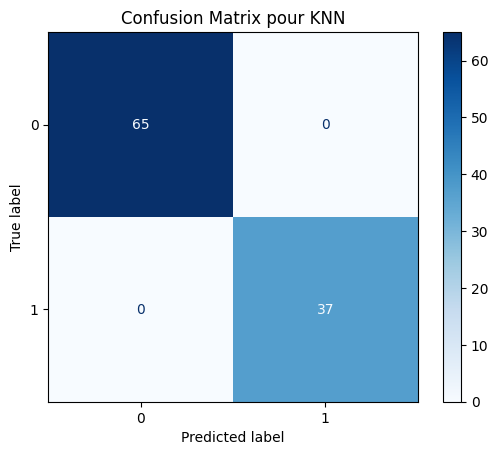

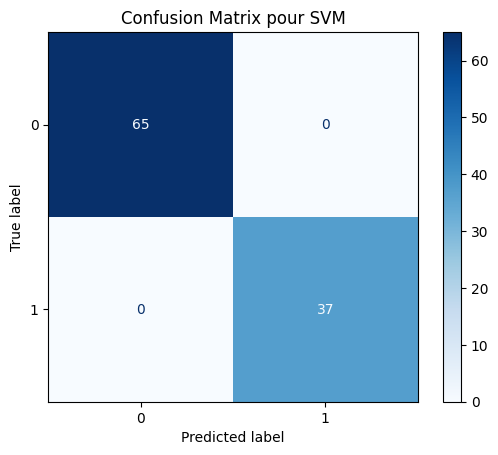

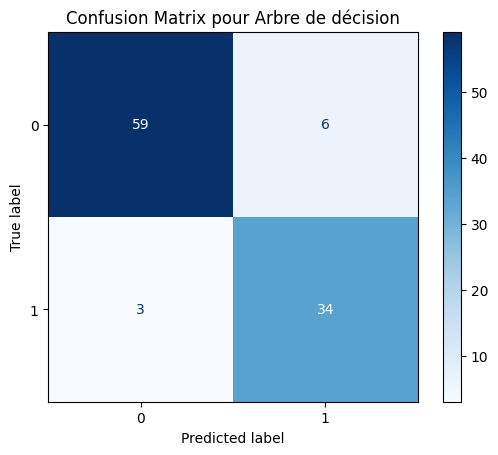

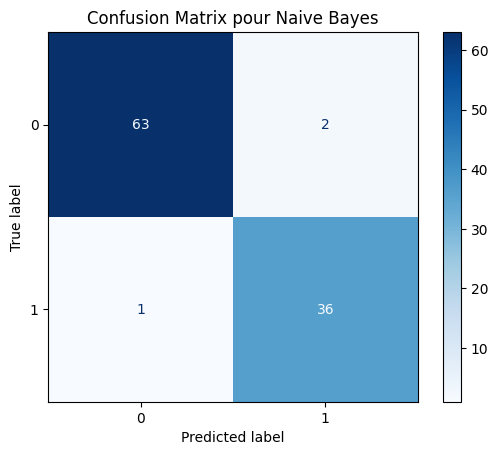

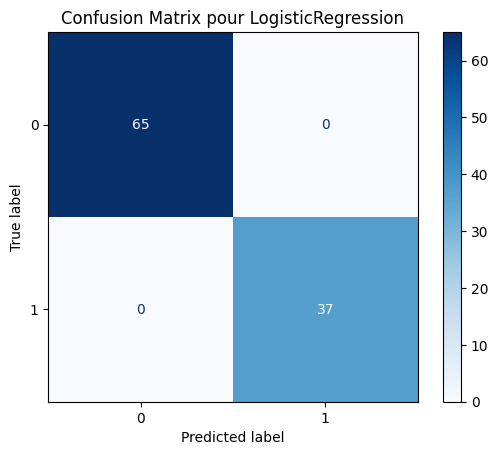


Top features sélectionnées (Mutual Information) :
['MZ2.7921478', 'MZ2.8234234', 'MZ25.49556', 'MZ25.589892', 'MZ25.684398', 'MZ25.779078', 'MZ220.47402', 'MZ220.75125', 'MZ221.86191', 'MZ222.14001', 'MZ222.41828', 'MZ222.69673', 'MZ222.97536', 'MZ223.25415', 'MZ243.49401', 'MZ243.78535', 'MZ244.07686', 'MZ244.36855', 'MZ244.66041', 'MZ244.95245', 'MZ245.24466', 'MZ245.53704', 'MZ245.8296', 'MZ246.12233', 'MZ246.41524', 'MZ246.70832', 'MZ247.00158', 'MZ247.295', 'MZ247.58861', 'MZ247.88239', 'MZ248.17634', 'MZ261.28267', 'MZ261.58446', 'MZ261.88643', 'MZ262.18857', 'MZ262.49088', 'MZ409.75936', 'MZ410.13727', 'MZ416.96946', 'MZ417.35068', 'MZ417.73207', 'MZ418.11364', 'MZ418.49538', 'MZ418.8773', 'MZ433.90794', 'MZ434.29682', 'MZ434.68588', 'MZ435.07512', 'MZ435.46452', 'MZ435.85411', 'MZ436.24386', 'MZ436.63379', 'MZ437.0239', 'MZ462.35287', 'MZ463.55767', 'MZ463.95962', 'MZ464.36174', 'MZ464.76404', 'MZ465.16651', 'MZ465.56916', 'MZ4003.6449', 'MZ4004.826', 'MZ7996.6231', 'MZ8003.30

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix pour {name}")
    plt.show()


print("\nTop features sélectionnées (Mutual Information) :")
print(list(selected_features))


MRMR

In [ ]:
!pip install pymrmr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pymrmr: filename=pymrmr-0.1.11-cp312-cp312-linux_x86_64.whl size=411151 sha256=f5dbdb7fdda045835efa0d31ca2c7c25f9132f073da31e406624d3f098c8ee96
  Stored in directory: /root/.cache/pip/wheels/d8/8b/01/15ccb01b7f3703042aef0458e113d6d3568c22d0a54c2974fb
Successfully built pymrmr


In [ ]:
import pymrmr
df_mrmr = df.copy()

for col in df_mrmr.columns:
    if df_mrmr[col].dtype == 'object':
        df_mrmr[col] = LabelEncoder().fit_transform(df_mrmr[col])

selected_mrmr = pymrmr.mRMR(df_mrmr, 'MIQ', 100)

X_mrmr = df_mrmr[selected_mrmr]
y_mrmr = df_mrmr.iloc[:, -1]

print("Nombre de features sélectionnées :", X_mrmr.shape[1])
print("Features sélectionnées :", selected_mrmr)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_mrmr_scaled, y_mrmr, test_size=0.4, random_state=42
)


from sklearn.linear_model import LogisticRegression

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "LogisticRegression": LogisticRegression()
}


results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc


print("\nComparaison des modèles (MRMR) :")
for name, acc in results.items():
    print(f"{name} : {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\nMeilleur modèle : {best_model} avec accuracy = {results[best_model]:.4f}")

In [ ]:
df_mrmr = df.copy()

for col in df_mrmr.columns:
    if df_mrmr[col].dtype == 'object':
        df_mrmr[col] = LabelEncoder().fit_transform(df_mrmr[col])

X_full = df_mrmr.iloc[:, :-1]
y_full = df_mrmr.iloc[:, -1]

print("Shape original:", X_full.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.4, random_state=42, stratify=y_full
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X_train_small = X_train.iloc[:, :1000]
X_test_small = X_test.iloc[:, :1000]

df_train = pd.concat([X_train_small, y_train], axis=1)

selected_mrmr = pymrmr.mRMR(df_train, 'MIQ', 50)

print("\nSelected features (MRMR):", selected_mrmr[:10], "...")

X_train_selected = X_train_small[selected_mrmr]
X_test_selected = X_test_small[selected_mrmr]

print("Features après MRMR:", X_train_selected.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", X_train_res.shape)

model = KNeighborsClassifier()

start = time.time()
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test_scaled)
end = time.time()

acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", acc)
print("Execution time:", round(end - start, 2), "sec")

for name, y_pred in predictions.items():
    print(f"\n Report pour {name} :")
    print(classification_report(y_test, y_pred))

Shape original: (253, 15154)
Train shape: (151, 15154)
Test shape: (102, 15154)

Selected features (MRMR): ['MZ38.521071', 'MZ38.289731', 'MZ38.985841', 'MZ38.869387', 'MZ38.753108', 'MZ38.637002', 'MZ39.219271', 'MZ38.405314', 'MZ39.453398', 'MZ38.174323'] ...
Features après MRMR: (151, 50)
After SMOTE: (194, 50)

Accuracy: 0.6666666666666666
Execution time: 0.0 sec

 Report pour KNN :
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        65
           1       0.92      0.95      0.93        37

    accuracy                           0.95       102
   macro avg       0.94      0.95      0.95       102
weighted avg       0.95      0.95      0.95       102


 Report pour SVM :
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        65
           1       1.00      0.92      0.96        37

    accuracy                           0.97       102
   macro avg       0.98      0.96      0.97  

Wrapper methode

SMOTE terminé en 0.01 sec | Nouvelles tailles: X_train=(194, 500), y_train=(194,)
SFS terminé en 383.25 sec
Nombre de features sélectionnées : 30
Features sélectionnées : ['MZ0.007133241', 'MZ0.012646311', 'MZ0.017192634', 'MZ0.022435711', 'MZ0.031606741', 'MZ0.054651894', 'MZ0.078646375', 'MZ0.12609535', 'MZ0.14676283', 'MZ0.15400037', 'MZ0.46476156', 'MZ0.47757313', 'MZ0.55810053', 'MZ0.78685372', 'MZ1.3619374', 'MZ1.4730262', 'MZ2.2032161', 'MZ2.5482141', 'MZ2.7921478', 'MZ2.9182952', 'MZ3.0798987', 'MZ3.5555556', 'MZ3.6262936', 'MZ3.8426881', 'MZ4.8118299', 'MZ7.027152', 'MZ7.5819514', 'MZ16.182479', 'MZ16.942029', 'MZ21.258449']
Training + prediction terminé en 0.00 sec
Accuracy : 0.9608
Confusion Matrix:
 [[61  4]
 [ 0 37]]


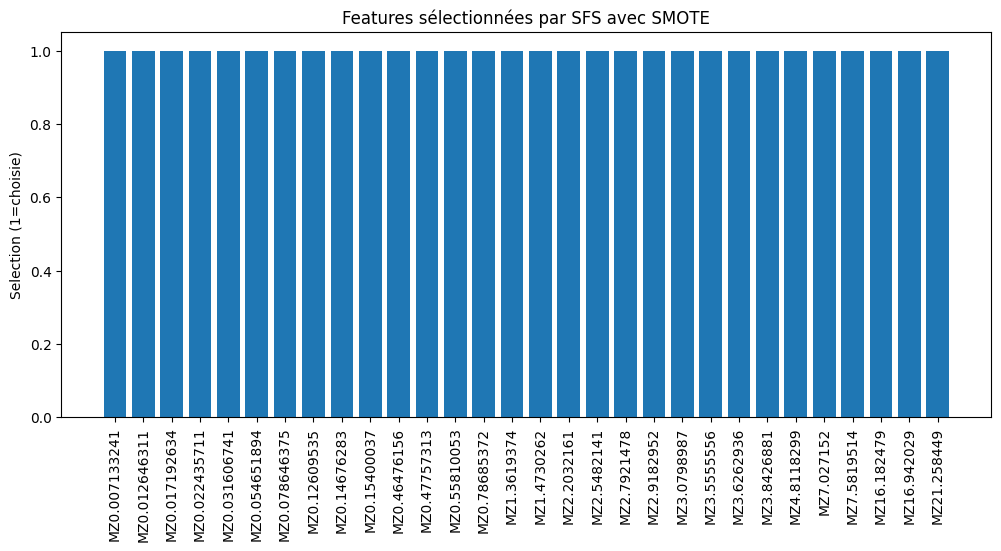

In [ ]:

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

subset_features = df.columns[:500]
X_small = df[subset_features]
y = df[df.columns[-1]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_small)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.4, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
start_smote = time.time()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
end_smote = time.time()
print(f"SMOTE terminé en {end_smote - start_smote:.2f} sec | "
      f"Nouvelles tailles: X_train={X_train_res.shape}, y_train={y_train_res.shape}")

knn = KNeighborsClassifier(n_neighbors=5)

sfs = SequentialFeatureSelector(
    knn,
    n_features_to_select=30,
    direction='forward',
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

start_sfs = time.time()
sfs.fit(X_train_res, y_train_res)
end_sfs = time.time()
print(f"SFS terminé en {end_sfs - start_sfs:.2f} sec")

selected_features = X_small.columns[sfs.get_support()]
print("Nombre de features sélectionnées :", len(selected_features))
print("Features sélectionnées :", list(selected_features))

X_train_sfs = X_train_res[:, sfs.get_support()]
X_test_sfs = X_test[:, sfs.get_support()]

start_train = time.time()
knn.fit(X_train_sfs, y_train_res)
y_pred = knn.predict(X_test_sfs)
end_train = time.time()
print(f"Training + prediction terminé en {end_train - start_train:.2f} sec")

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy : {acc:.4f}")
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(12,5))
plt.bar(range(len(selected_features)), [1]*len(selected_features))
plt.xticks(range(len(selected_features)), selected_features, rotation=90)
plt.title("Features sélectionnées par SFS avec SMOTE")
plt.ylabel("Selection (1=choisie)")
plt.show()

SMOTE terminé en 0.00 sec | Nouvelles tailles: X_train=(194, 500), y_train=(194,)
SFS terminé en 368.64 sec
Nombre de features sélectionnées : 30
Features sélectionnées : ['MZ0.007133241', 'MZ0.012646311', 'MZ0.017192634', 'MZ0.022435711', 'MZ0.031606741', 'MZ0.054651894', 'MZ0.078646375', 'MZ0.12609535', 'MZ0.14676283', 'MZ0.15400037', 'MZ0.46476156', 'MZ0.47757313', 'MZ0.55810053', 'MZ0.78685372', 'MZ1.3619374', 'MZ1.4730262', 'MZ2.2032161', 'MZ2.5482141', 'MZ2.7921478', 'MZ2.9182952', 'MZ3.0798987', 'MZ3.5555556', 'MZ3.6262936', 'MZ3.8426881', 'MZ4.8118299', 'MZ7.027152', 'MZ7.5819514', 'MZ16.182479', 'MZ16.942029', 'MZ21.258449']

Résultats de tous les modèles :
KNN : Accuracy=0.9608 | Temps=0.00 sec
SVM : Accuracy=0.9804 | Temps=0.01 sec
Decision Tree : Accuracy=0.8627 | Temps=0.00 sec
Naive Bayes : Accuracy=0.9412 | Temps=0.00 sec

Meilleur modèle : SVM avec accuracy = 0.9804

Report pour KNN :
              precision    recall  f1-score   support

           0       1.00      0.

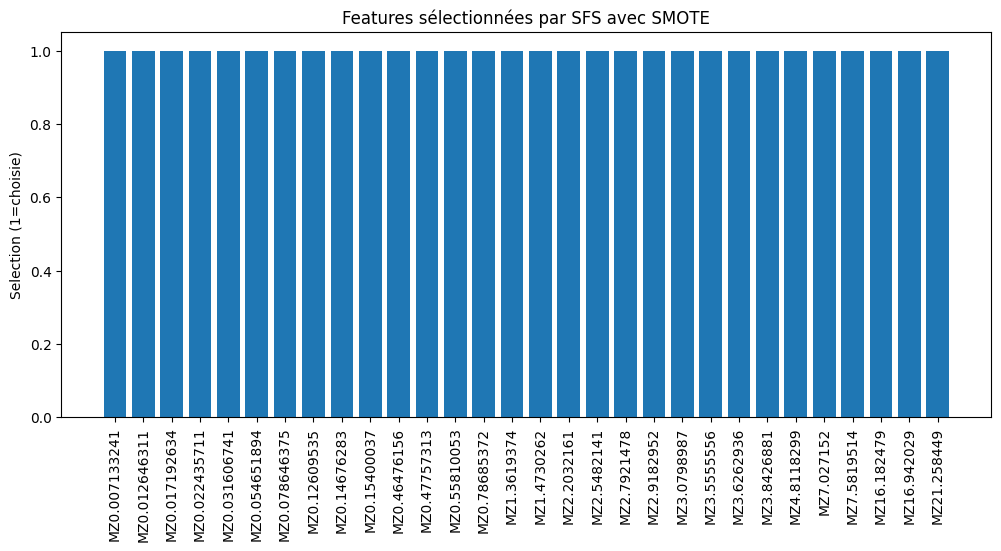

In [ ]:
df = pd.read_csv("dataset.csv")

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

subset_features = df.columns[:500]
X_small = df[subset_features]
y = df[df.columns[-1]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_small)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.4, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
start_smote = time.time()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
end_smote = time.time()
print(f"SMOTE terminé en {end_smote - start_smote:.2f} sec | "
      f"Nouvelles tailles: X_train={X_train_res.shape}, y_train={y_train_res.shape}")

from sklearn.linear_model import LogisticRegression

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "LogisticRegression": LogisticRegression()
}

knn = models["KNN"]
sfs = SequentialFeatureSelector(
    knn,
    n_features_to_select=30,
    direction='forward',
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

start_sfs = time.time()
sfs.fit(X_train_res, y_train_res)
end_sfs = time.time()
selected_features = X_small.columns[sfs.get_support()]
print(f"SFS terminé en {end_sfs - start_sfs:.2f} sec")
print("Nombre de features sélectionnées :", len(selected_features))
print("Features sélectionnées :", list(selected_features))

X_train_sfs = X_train_res[:, sfs.get_support()]
X_test_sfs = X_test[:, sfs.get_support()]

results = {}
execution_times = {}
predictions = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_sfs, y_train_res)
    y_pred = model.predict(X_test_sfs)
    end_time = time.time()

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    execution_times[name] = end_time - start_time
    predictions[name] = y_pred

print("\nRésultats de tous les modèles :")
for name in models.keys():
    print(f"{name} : Accuracy={results[name]:.4f} | Temps={execution_times[name]:.2f} sec")

best_model = max(results, key=results.get)
print(f"\nMeilleur modèle : {best_model} avec accuracy = {results[best_model]:.4f}")

for name, y_pred in predictions.items():
    print(f"\nReport pour {name} :")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(12,5))
plt.bar(range(len(selected_features)), [1]*len(selected_features))
plt.xticks(range(len(selected_features)), selected_features, rotation=90)
plt.title("Features sélectionnées par SFS avec SMOTE")
plt.ylabel("Selection (1=choisie)")
plt.show()